# About the dataset

---------------------

* The dataset contain 35,685 examples of 48x48 pixel gray scale images of faces divided into train and test dataset. Images are categorized based on the emotion shown in the facial expressions (happiness, neutral, sadness, anger, surprise, disgust, fear).

--------------------

# Exploring data

---------------------

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import cv2

In [3]:
# Set path to training folder
train_dir = r"C:\Users\dell\Downloads\train"

data = []

# Loop through each class folder
for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                filepath = os.path.join(class_dir, filename)
                data.append([filepath, label])

train = pd.DataFrame(data, columns=["filepath", "label"])

In [13]:
train.head()

,filepath,label
0,C:\Users\dell\Downloads\train\angry\im0.png,angry
1,C:\Users\dell\Downloads\train\angry\im1.png,angry
2,C:\Users\dell\Downloads\train\angry\im10.png,angry
3,C:\Users\dell\Downloads\train\angry\im100.png,angry
4,C:\Users\dell\Downloads\train\angry\im1000.png,angry


In [17]:
train.shape

(28709, 2)

In [5]:
# Set path to your testing folder
test_dir = r"C:\Users\dell\Downloads\test"

data = []

# Loop through each class folder
for label in os.listdir(test_dir):
    class_dir = os.path.join(test_dir, label)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                filepath = os.path.join(class_dir, filename)
                data.append([filepath, label])

test = pd.DataFrame(data, columns=["filepath", "label"])

In [29]:
test.head()

,filepath,label
0,C:\Users\dell\Downloads\test\angry\im0.png,angry
1,C:\Users\dell\Downloads\test\angry\im1.png,angry
2,C:\Users\dell\Downloads\test\angry\im10.png,angry
3,C:\Users\dell\Downloads\test\angry\im100.png,angry
4,C:\Users\dell\Downloads\test\angry\im101.png,angry


In [31]:
test.shape

(7178, 2)

In [7]:
full_df = pd.concat([train, test], ignore_index=True)

In [35]:
full_df.head()

,filepath,label
0,C:\Users\dell\Downloads\train\angry\im0.png,angry
1,C:\Users\dell\Downloads\train\angry\im1.png,angry
2,C:\Users\dell\Downloads\train\angry\im10.png,angry
3,C:\Users\dell\Downloads\train\angry\im100.png,angry
4,C:\Users\dell\Downloads\train\angry\im1000.png,angry


In [37]:
full_df.shape

(35887, 2)

In [37]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  35887 non-null  object
 1   label     35887 non-null  object
dtypes: object(2)
memory usage: 560.9+ KB


In [41]:
full_df.isna().sum()

filepath    0
label       0
dtype: int64

In [43]:
full_df.duplicated().sum()

0

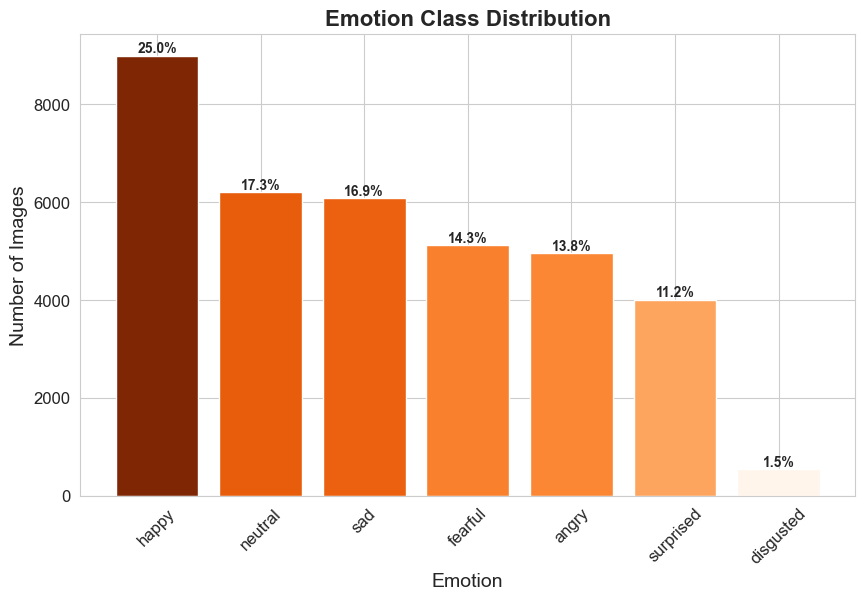

In [33]:
# Count of each class, sorted descending
class_counts = full_df['label'].value_counts().sort_values(ascending=False)
labels = class_counts.index
values = class_counts.values

# Normalize counts to [0,1] for coloring
norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
cmap = plt.cm.Oranges
colors = [cmap(norm(val)) for val in values]

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(labels, values, color=colors)

# Rotate x-axis labels
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Title and axis labels
plt.title("Emotion Class Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Emotion", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)

# Annotate bars with percentages
total = values.sum()
for bar, val in zip(bars, values):
    percentage = f"{100*val/total:.1f}%"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), percentage,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


In [35]:
full_df['label'].value_counts()

label
happy        8989
neutral      6198
sad          6077
fearful      5121
angry        4953
surprised    4002
disgusted     547
Name: count, dtype: int64

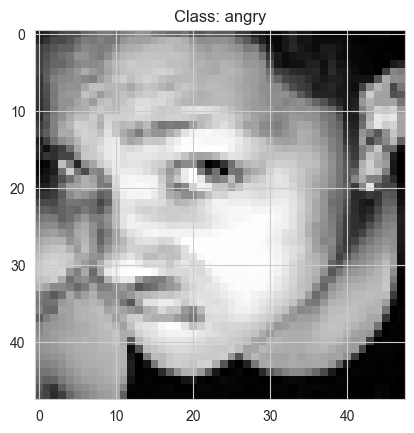

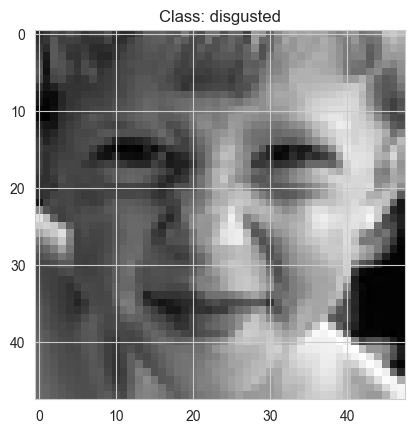

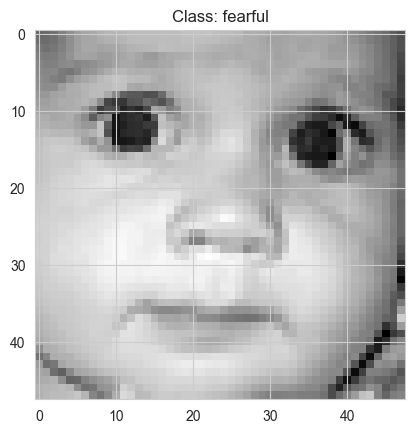

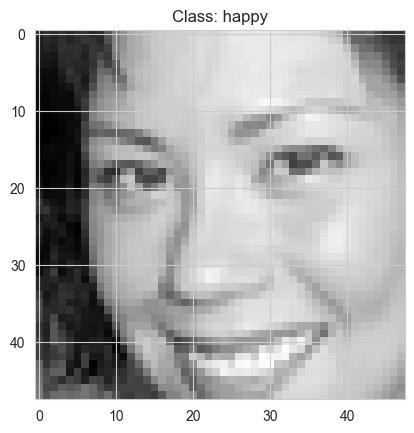

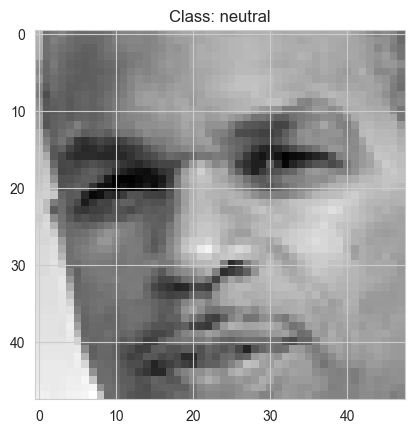

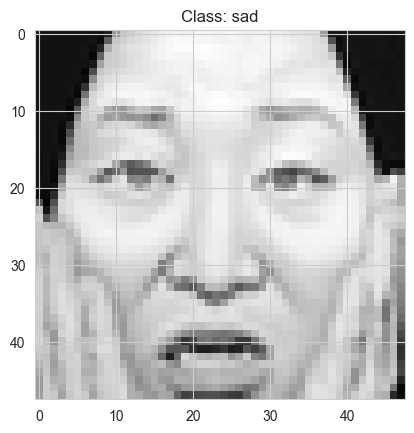

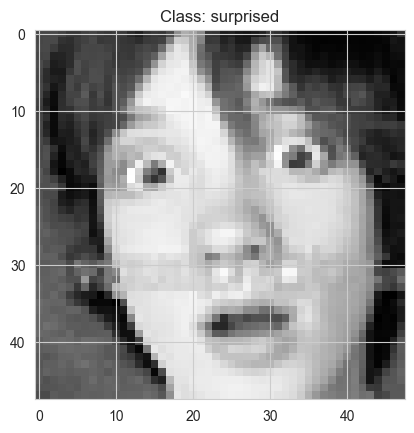

In [43]:
classes = full_df['label'].unique()
for cls in classes:
    sample = full_df[full_df['label'] == cls].sample(1)
    img = Image.open(sample['filepath'].values[0]).convert('L')  # grayscale
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {cls}")
    plt.show()

In [47]:
# Function to get image size
def check_size(filepath):
    img = Image.open(filepath)
    return img.size  # returns (width, height)

# Apply to all images
sizes = full_df['filepath'].apply(check_size)

# Check if all are 48x48
all_correct_size = all(s == (48,48) for s in sizes)
print("All images are 48x48?", all_correct_size)

# If some are not, see which ones
incorrect_sizes = full_df[sizes != (48,48)]
print("Images with wrong size:")
print(incorrect_sizes)

All images are 48x48? True
Images with wrong size:
Empty DataFrame
Columns: [filepath, label]
Index: []


In [49]:
# Function to check image mode
def check_mode(filepath):
    img = Image.open(filepath)
    return img.mode  # 'L' = grayscale, 'RGB' = color

modes = full_df['filepath'].apply(check_mode)

# Check if all are grayscale
all_grayscale = all(m == 'L' for m in modes)
print("All images are grayscale?", all_grayscale)

# If some are not, see which ones
non_grayscale = full_df[modes != 'L']
print("Images not grayscale:")
print(non_grayscale)

All images are grayscale? True
Images not grayscale:
Empty DataFrame
Columns: [filepath, label]
Index: []


----------------------------

* I merged the training and testing datasets into one dataset
* The full dataset contains 35887 rows and 2 columns
* The dataset contains no null values nor duplicates
* The dataset is unbalanced
* All imaged have the same size which is 48x48
* All imaged are grayscale

--------------------------------------------------------------

# Preprocessing

-----------------------------------

* Why grayscale?
  * Emotions can often be detected from facial expressions without color information. Grayscale reduces input size (1 channel instead of 3), so the model trains faster with less memory.

* Why resize to 48×48?
  * Neural networks need inputs of the same size.

* Why convert to NumPy arrays?
  * ML models work with numbers, not images. So we turn pixels into numerical arrays (0–255).

* Why stack images into X?
  * Neural networks process many samples at once in batches. So we need one big array containing all images.
  * Example: instead of having 10,000 separate arrays, we create X with shape (10000, 48, 48).

* Normalize images
  * Pixel values are originally 0–255 (black = 0, white = 255).
  * Neural networks work better with small, normalized numbers (0–1).
  * Speeds up training.
  * Prevents exploding/vanishing gradients.
  * Ensures fair weight updates across layers.

* Reshape for CNN input (X = X.reshape(-1, 48, 48, 1))
  * CNNs expect a 4D tensor: (samples, height, width, channels).
  * -1 = "let NumPy figure out how many samples we have".
  * Since grayscale → channels=1. If RGB, it would be 3.

* All of this is data preprocessing: turning raw data (images + labels) into a format a CNN can actually learn from.

In [54]:
# ---------- Convert image paths into numpy arrays ----------
def img_to_array(filepath):
    img = Image.open(filepath).convert('L')  # already grayscale
    img = img.resize((48, 48))               # ensure 48x48
    return np.array(img)


In [56]:
full_df['image_array'] = full_df['filepath'].apply(img_to_array)

In [74]:
# ---------- Encoding labels ----------
label_map = {
    "happy": 0,
    "neutral": 1,
    "sad": 2,
    "fearful": 3,
    "angry": 4,
    "surprised": 5,
    "disgusted": 6
}
full_df['label_encoded'] = full_df['label'].map(label_map)

In [76]:
# ----------  Convert to numpy arrays ----------
X = np.stack(full_df['image_array'].values)   # shape: (num_samples, 48, 48)
y = full_df['label_encoded'].values            # shape (N,)

In [78]:
# ---------- Normalize images ----------
X = X.astype("float32") / 255.0  # scale 0–255 → 0–1

In [80]:
# ---------- 4. Reshape for CNN input ----------
X = X.reshape(-1, 48, 48, 1)  # (samples, height, width, channels)

In [82]:
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (35887, 48, 48, 1)
Final y shape: (35887,)


# CNN Models

* CNN (Convolutional Neural Network) is a type of neural network designed for image data.
* Why CNN for images?
  * If we fed a raw 48×48 image (2304 pixels) directly into a normal neural network:
    * Each pixel would be treated independently (loses spatial info).
    * The network would have millions of parameters → too slow and overfits.
    * CNNs fix this by using convolutions, which look at small regions of the image and share weights.
* How CNN works
  * Input Layer
  * Convolution Layer
   * Applies filters (kernels) that scan over the image.
   * Each filter detects a feature (like an edge, curve, or texture).
   * The result is a feature map showing where that feature occurs.
  * Activation Function (ReLU)
    * Keeps only positive values (nonlinear transformation).
    * Helps the network learn complex patterns.
  * Pooling Layer (Downsampling)
    * Reduces image size while keeping important info.
    * max pooling takes the max value in a small region (keeps strongest feature).
  * More Convolution + Pooling Layers
    * Deeper layers learn more abstract features:
      * Early layers → edges & corners.
      * Middle layers → shapes & textures.
      * Deep layers → full objects (like a mouth or eye).
  * Flatten Layer
    * Converts 2D feature maps into a 1D vector to feed into dense (fully connected) layers.
  * Fully Connected (Dense) Layers
    * Combine features to make a decision.
  * Output Layer
    * Uses Softmax for classification.


In [182]:
# ----------  Train-test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,shuffle= True
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (28709, 48, 48, 1)
y_train shape: (28709,)
X_test shape: (7178, 48, 48, 1)
y_test shape: (7178,)


In [104]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')  # number of classes
])

E:\ANACONDA\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* Sequential means the model is a linear stack of layers: one layer feeds directly into the next.
* First Convolution + Pooling Block:
  * Conv2D(32, (3,3)):
    * Applies 32 filters, each of size 3x3, that “scan” across the image.
    * Filters detect low-level features like edges, corners, textures.
  * activation='relu':
    * ReLU (Rectified Linear Unit) introduces non-linearity → keeps only positive values.
  * input_shape=(48,48,1):
    * Input is a 48x48 grayscale image (the 1 channel means grayscale, not RGB).
  * MaxPooling2D((2,2)):
    * Reduces the size of the feature maps by taking the max value in each 2x2 block → keeps strongest features and reduces computation.

* Second Convolution + Pooling Block
  * Another convolution, now with 64 filters.
  * hese detect more complex patterns (shapes, eyes, mouth edges, etc.).
  * Pooling again reduces size and helps avoid overfitting.

* Third Convolution + Pooling Block
  * Even deeper layer with 128 filters.
  * Now the model is detecting high-level features (like full facial expressions).
  * More filters = more abstract features.

* Flatten Layer
  * Converts the 2D feature maps into a 1D vector so they can be fed into fully connected (Dense) layers.


* Fully Connected Dense Layer
  * A dense layer with 128 neurons.
  * Each neuron connects to all extracted features.
  * earns complex combinations of features → makes the model capable of classifying emotions.

* Dropout Layer
  * Randomly drops 50% of the neurons during training.
  * Prevents overfitting (when model memorizes training data instead of generalizing).
    
* Output Layer
  * Output neurons = number of emotion classes
  * softmax: turns raw outputs into probabilities for each class (they add up to 1).

In [106]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [108]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 111ms/step - accuracy: 0.2890 - loss: 1.7507 - val_accuracy: 0.4090 - val_loss: 1.5476
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.4183 - loss: 1.5113 - val_accuracy: 0.4682 - val_loss: 1.4054
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.4683 - loss: 1.3916 - val_accuracy: 0.4974 - val_loss: 1.2976
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.4997 - loss: 1.3169 - val_accuracy: 0.5288 - val_loss: 1.2255
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 48s 108ms/step - accuracy: 0.5256 - loss: 1.2654 - val_accuracy: 0.5417 - val_loss: 1.2007
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 48s 107ms/step - accuracy: 0.5454 - loss: 1.2118 - val_accuracy: 0.5425 - val_loss: 1.1976
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 48s 107ms/step - accuracy: 0.5594 - loss: 1.1654 - val_accuracy: 0.5520 - val_loss: 1.1617
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 48s 107ms/step - accuracy: 0.5773 - loss: 1

In [109]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5631 - loss: 1.6921
Test Accuracy: 0.5631095170974731


In [192]:
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])


E:\ANACONDA\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [194]:
opt = Adam(learning_rate=0.001)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

model2.compile(
    optimizer=opt,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [196]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [161]:
history = model2.fit(
    X_train, y_train, batch_size=64,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[reduce_lr, early_stop]
)


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2238 - loss: 2.4078

449/449 ━━━━━━━━━━━━━━━━━━━━ 217s 451ms/step - accuracy: 0.2831 - loss: 2.0709 - val_accuracy: 0.2963 - val_loss: 1.7089 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.3978 - loss: 1.5782

449/449 ━━━━━━━━━━━━━━━━━━━━ 202s 451ms/step - accuracy: 0.4194 - loss: 1.5197 - val_accuracy: 0.4347 - val_loss: 1.4322 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.4610 - loss: 1.4028

449/449 ━━━━━━━━━━━━━━━━━━━━ 202s 449ms/step - accuracy: 0.4742 - loss: 1.3682 - val_accuracy: 0.4900 - val_loss: 1.3264 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.5043 - loss: 1.2923

449/449 ━━━━━━━━━━━━━━━━━━━━ 204s 455ms/step - accuracy: 0.5083 - loss: 1.2845 - val_accuracy: 0.5017 - val_loss: 1.2906 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.5257 - loss: 1.2363

...

449/449 ━━━━━━━━━━━━━━━━━━━━ 144s 321ms/step - accuracy: 0.6796 - loss: 0.8537 - val_accuracy: 0.6119 - val_loss: 1.0872 - learning_rate: 0.0010
Epoch 18/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7093 - loss: 0.7808

449/449 ━━━━━━━━━━━━━━━━━━━━ 150s 333ms/step - accuracy: 0.7110 - loss: 0.7757 - val_accuracy: 0.6244 - val_loss: 1.0639 - learning_rate: 5.0000e-04
Epoch 19/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.7287 - loss: 0.7313

449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 315ms/step - accuracy: 0.7249 - loss: 0.7432 - val_accuracy: 0.6304 - val_loss: 1.0546 - learning_rate: 5.0000e-04
Epoch 20/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7419 - loss: 0.7000

449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 316ms/step - accuracy: 0.7341 - loss: 0.7186 - val_accuracy: 0.6369 - val_loss: 1.0375 - learning_rate: 5.0000e-04
Epoch 21/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 314ms/step - accuracy: 0.7446 - loss: 0.6899 - val_accuracy: 0.6330 - val_loss: 1.0608 - learning_rate: 5.0000e-04
Epoch 22/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 146s 325ms/step - accuracy: 0.7509 - loss: 0.6706 - val_accuracy: 0.6343 - val_loss: 1.0678 - learning_rate: 5.0000e-04
Epoch 23/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 147s 327ms/step - accuracy: 0.7549 - loss: 0.6580 - val_accuracy: 0.6357 - val_loss: 1.0846 - learning_rate: 5.0000e-04
Epoch 24/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 317ms/step - accuracy: 0.7637 - loss: 0.6391 - val_accuracy: 0.6328 - val_loss: 1.0853 - learning_rate: 5.0000e-04
Epoch 25/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.7748 - loss: 0.6161
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 314ms/s

449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 315ms/step - accuracy: 0.7871 - loss: 0.5757 - val_accuracy: 0.6415 - val_loss: 1.0984 - learning_rate: 2.5000e-04
Epoch 27/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 140s 312ms/step - accuracy: 0.7966 - loss: 0.5497 - val_accuracy: 0.6400 - val_loss: 1.1079 - learning_rate: 2.5000e-04
Epoch 28/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 145s 323ms/step - accuracy: 0.7991 - loss: 0.5431 - val_accuracy: 0.6386 - val_loss: 1.1138 - learning_rate: 2.5000e-04
Epoch 29/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 317ms/step - accuracy: 0.8050 - loss: 0.5266 - val_accuracy: 0.6382 - val_loss: 1.1606 - learning_rate: 2.5000e-04
Epoch 30/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8091 - loss: 0.5176
Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
449/449 ━━━━━━━━━━━━━━━━━━━━ 188s 418ms/step - accuracy: 0.8075 - loss: 0.5211 - val_accuracy: 0.6396 - val_loss: 1.1445 - learning_rate: 2.5000e-04


In [184]:
test_loss, test_acc = model2.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.8084 - loss: 0.5599
Test Accuracy: 0.8084424734115601


In [198]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))


In [200]:
history = model2.fit(
    X_train, y_train,
    batch_size=64,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[reduce_lr, early_stop],
    class_weight=class_weights
)


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 300ms/step - accuracy: 0.1910 - loss: 2.3033 - val_accuracy: 0.2860 - val_loss: 1.8549 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 136s 303ms/step - accuracy: 0.2990 - loss: 1.7870 - val_accuracy: 0.3970 - val_loss: 1.5690 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 162s 361ms/step - accuracy: 0.3688 - loss: 1.5915 - val_accuracy: 0.4171 - val_loss: 1.5149 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 449ms/step - accuracy: 0.4120 - loss: 1.4887 - val_accuracy: 0.4774 - val_loss: 1.3747 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 206s 459ms/step - accuracy: 0.4397 - loss: 1.4237 - val_accuracy: 0.4901 - val_loss: 1.3434 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 202s 450ms/step - accuracy: 0.4641 - loss: 1.3485 - val_accuracy: 0.4302 - val_loss: 1.4663 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 448ms/step - accura

In [202]:
test_loss, test_acc = model2.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6063 - loss: 1.0515
Test Accuracy: 0.6062970161437988


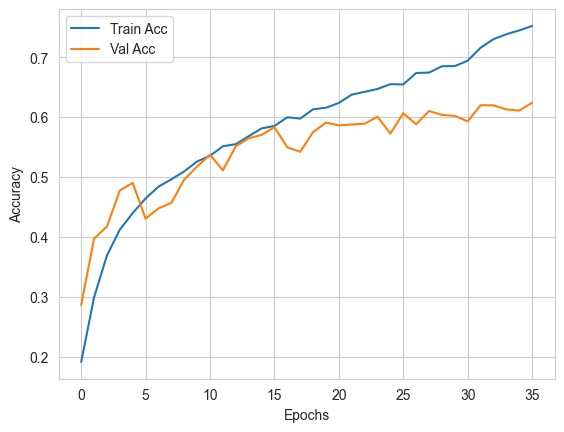

In [204]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

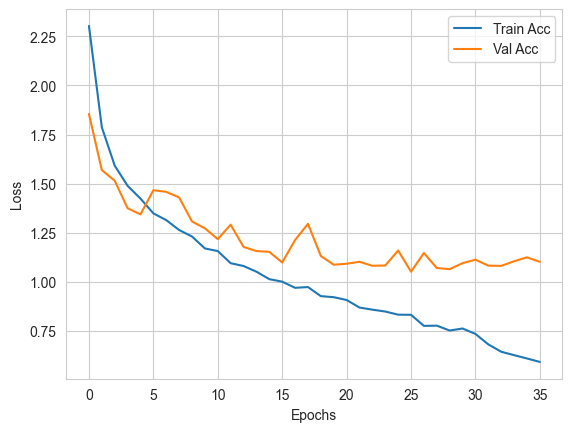

In [206]:
plt.plot(history.history['loss'], label='Train Acc')
plt.plot(history.history['val_loss'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [208]:
model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 44, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,264,311 (4.82 MB)

 Trainable params: 420,967 (1.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 841,936 (3.21 MB)

In [19]:
# ---------- Label mapping ----------
label_map = {
    "happy": 0,
    "neutral": 1,
    "sad": 2,
    "fearful": 3,
    "angry": 4,
    "surprised": 5,
    "disgusted": 6
}

# Invert mapping (num → class name)
inv_label_map = {v: k for k, v in label_map.items()}

# ---------- Prediction function ----------
def predict_emotion(model, img_path):
    # Load and preprocess image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale
    img = cv2.resize(img, (48, 48))                  # resize to 48x48
    img = img.astype("float32") / 255.0              # normalize 0-1
    img = np.expand_dims(img, axis=-1)               # add channel dim
    img = np.expand_dims(img, axis=0)                # add batch dim

    # Predict
    probs = model.predict(img)[0]  # shape (7,)
    
    # Print probabilities for each class
    for i, p in enumerate(probs):
        print(f"{inv_label_map[i]}: {p:.4f}")

    # Final prediction
    pred_idx = np.argmax(probs)
    pred_label = inv_label_map[pred_idx]
    print(f"\nFinal Prediction: {pred_label} ({probs[pred_idx]:.4f})")

    return pred_label, probs

pred_label, probs = predict_emotion(cnn_model,r"C:\Users\dell\Downloads\sad6.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
happy: 0.0293
neutral: 0.0318
sad: 0.8246
fearful: 0.0272
angry: 0.0704
surprised: 0.0001
disgusted: 0.0167

Final Prediction: sad (0.8246)


In [250]:
model2.save("cnn_model.keras")


In [7]:
cnn_model = load_model("cnn_model.keras")